In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, f1_score , recall_score, confusion_matrix ,precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
warnings.filterwarnings('ignore')

In [52]:
df = pd.read_csv("loan_data.csv")
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [54]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


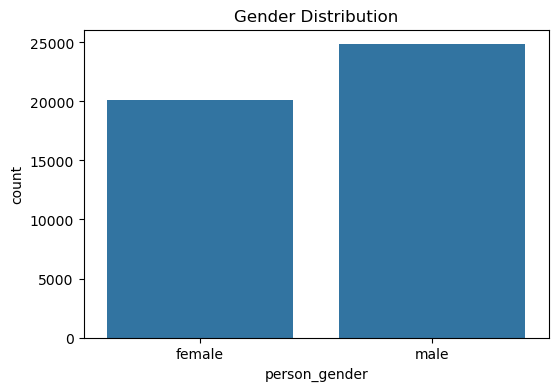

In [55]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="person_gender")

plt.title("Gender Distribution")
plt.show()

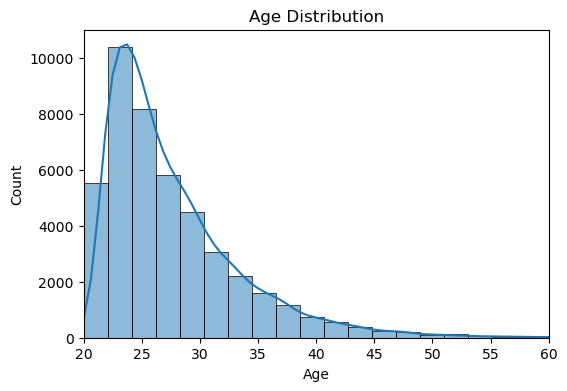

In [56]:
plt.figure(figsize=(6,4))

sns.histplot(df["person_age"], bins=60, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.xlim(20, 60)

plt.show()

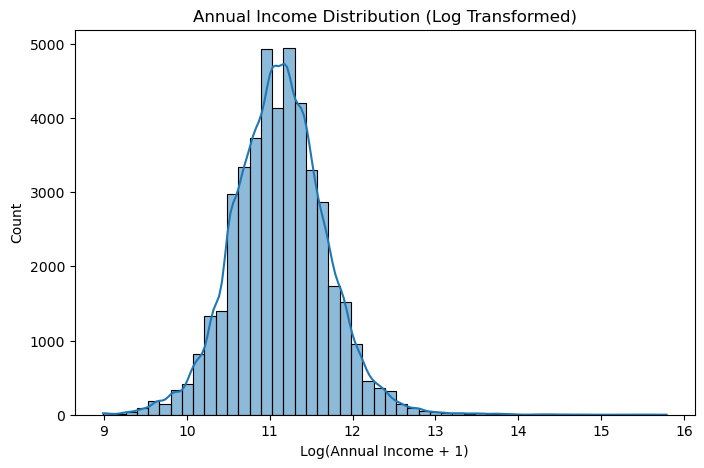

In [57]:
plt.figure(figsize=(8,5))

sns.histplot(np.log1p(df["person_income"]), bins=50, kde=True)

plt.title("Annual Income Distribution (Log Transformed)")

plt.xlabel("Log(Annual Income + 1)")

plt.show()

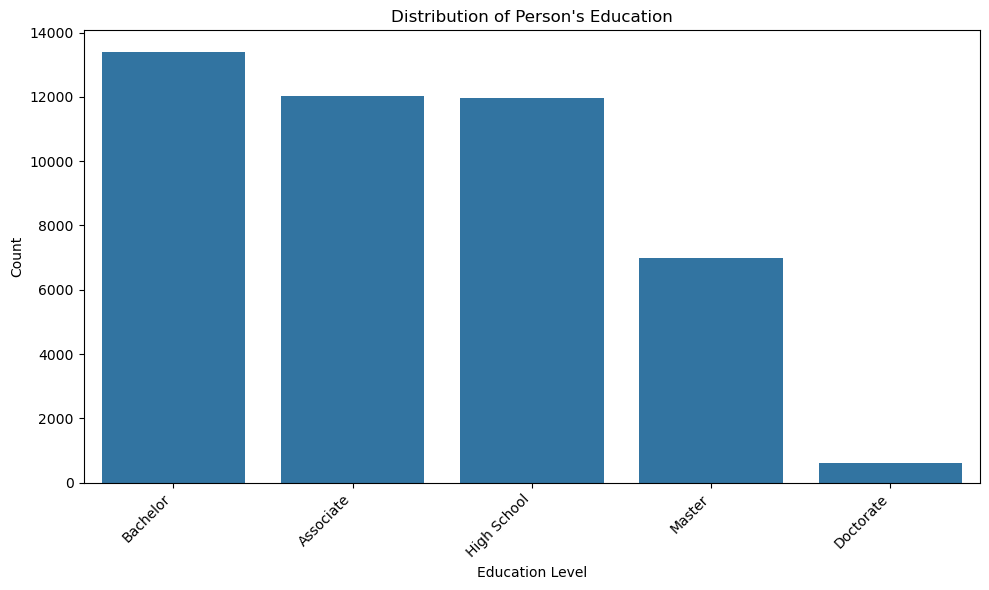

In [58]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="person_education", order=df["person_education"].value_counts().index)
plt.title("Distribution of Person's Education")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [59]:
import plotly.express as px

fig = px.box(df, y = "person_income", color = "person_gender",
             points = "all", notched = True,
             color_discrete_sequence = ["#0044FF", "#DE00FF"],
             title = "Male and Female Annual Income (k$)")

fig.update_traces(marker = dict(size = 5, symbol = "circle-open"))
fig.update_traces(fillcolor = "#000000")
fig.update_layout(template = "plotly_dark")

fig.show()

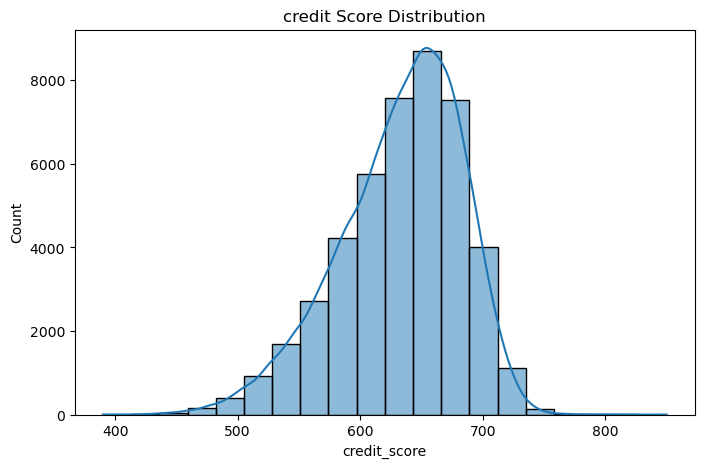

In [60]:
plt.figure(figsize=(8,5))

sns.histplot(df["credit_score"], bins=20, kde=True)

plt.title("credit Score Distribution")

plt.show()

In [61]:
# DATA PREPROCESSING
# 1. Missing Values Handling
# 1. Missing Values Handling
missing_vals = df.isnull().sum()
if missing_vals.sum() > 0:
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())
            
# 2. Feature and Target Separation
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# 3. Categorical Encoding
categorical_cols = X.select_dtypes(include=['object']).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# 5. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

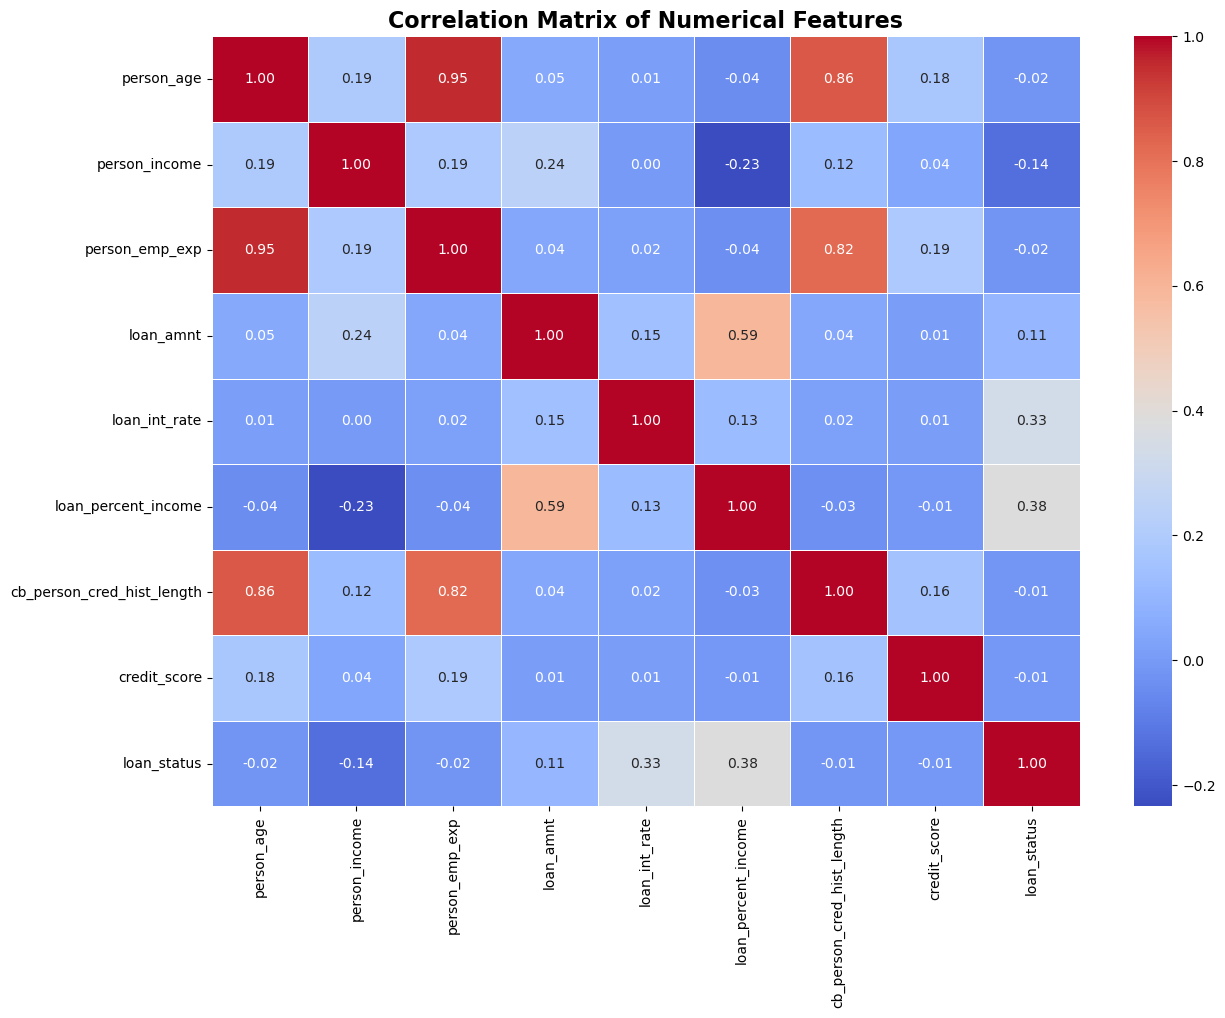

In [62]:
# Correlation Matrix
plt.figure(figsize=(14, 10))
num_df = df.select_dtypes(include=[np.number])
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.show()

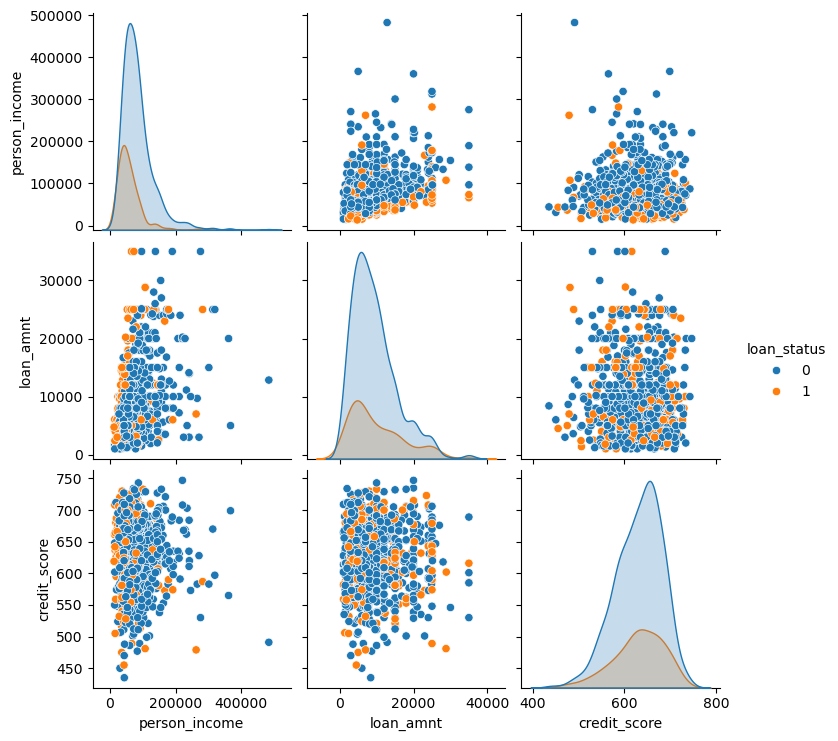

In [63]:
sns.pairplot(
    df.sample(1000, random_state=42),
    vars=[
        "person_income",
        "loan_amnt",
        "credit_score"
    ],
    hue="loan_status"
)

plt.show()

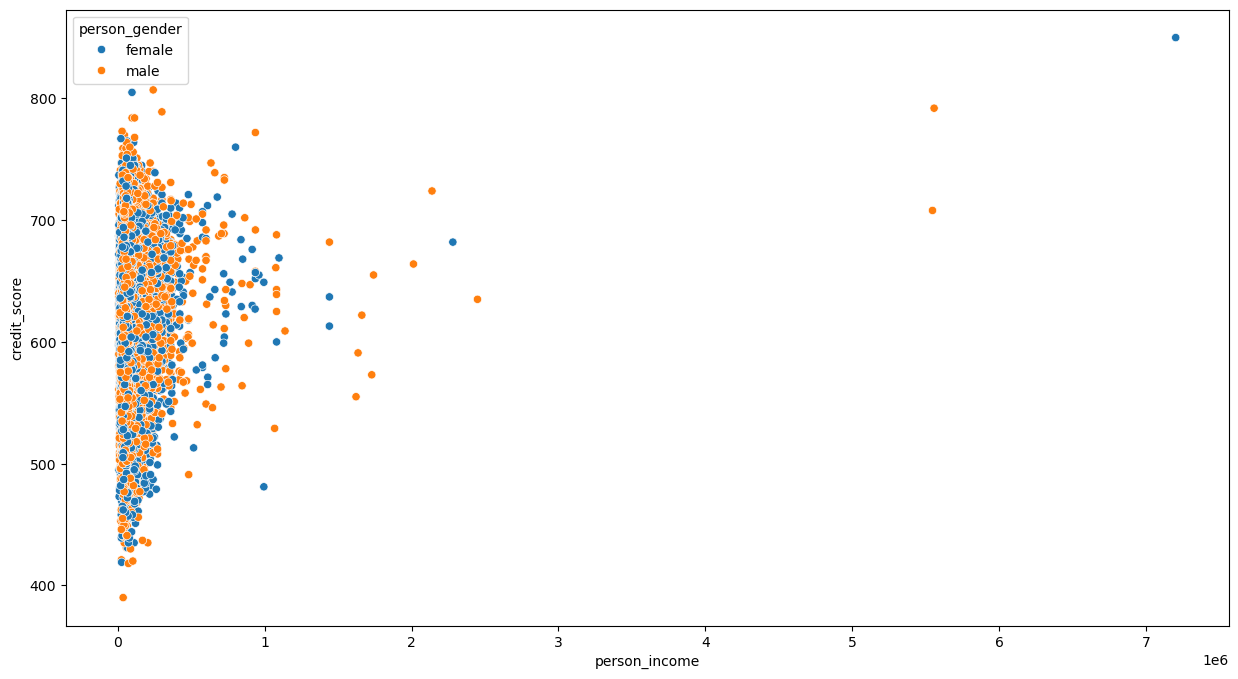

In [64]:
plt.figure(figsize=(15, 8))

sns.scatterplot(data=df, x='person_income', y='credit_score', hue='person_gender');

In [65]:
# Fit PCA
pca_full = PCA().fit(X_train_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

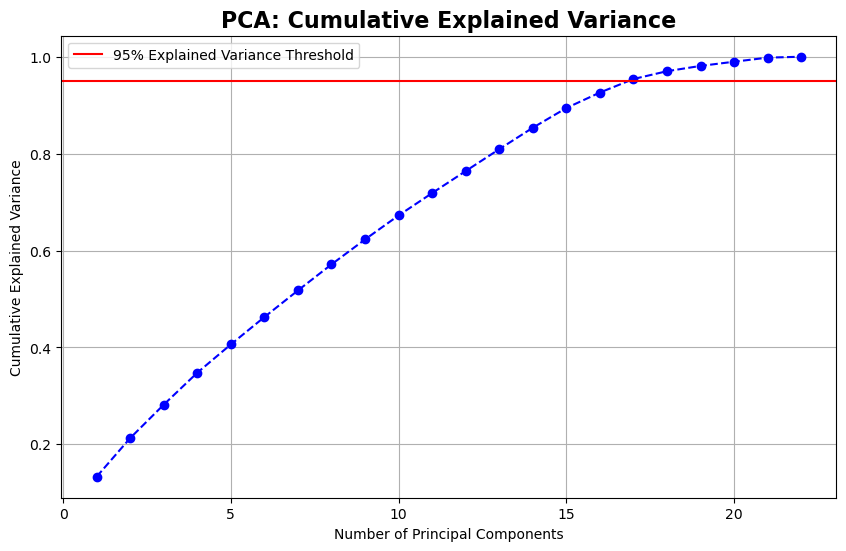

22 to 17 components.


In [66]:
# Explained Variance Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance Threshold')
plt.title('PCA: Cumulative Explained Variance', fontsize=16, fontweight='bold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

# Transform data retaining 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"{X_train_scaled.shape[1]} to {X_train_pca.shape[1]} components.")

Logistic Regression       
 [[6601  399]
 [ 503 1497]] 
               precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.79      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000



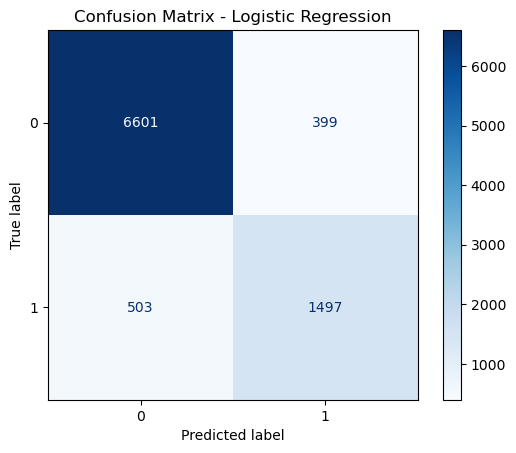

Logistic Regression       |ROC_AUC: 0.8458 
Random Forest             
 [[6820  180]
 [ 462 1538]] 
               precision    recall  f1-score   support

           0       0.94      0.97      0.96      7000
           1       0.90      0.77      0.83      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



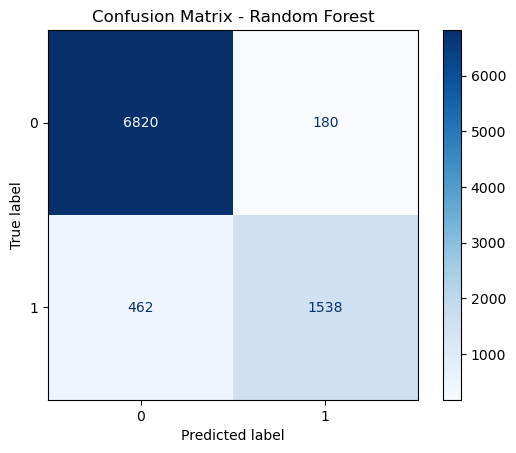

Random Forest             |ROC_AUC: 0.8716 
XGBoost                   
 [[6808  192]
 [ 373 1627]] 
               precision    recall  f1-score   support

           0       0.95      0.97      0.96      7000
           1       0.89      0.81      0.85      2000

    accuracy                           0.94      9000
   macro avg       0.92      0.89      0.91      9000
weighted avg       0.94      0.94      0.94      9000



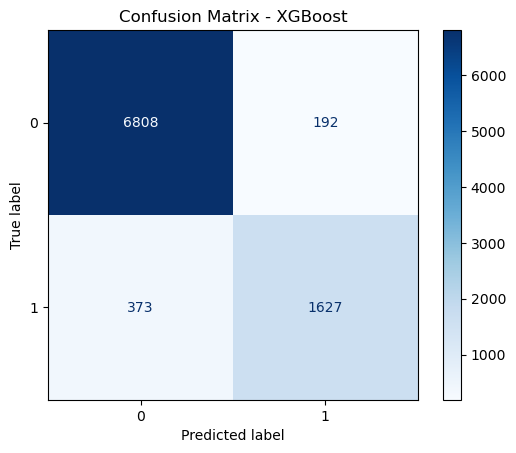

XGBoost                   |ROC_AUC: 0.8930 
Gradient Boosting         
 [[6790  210]
 [ 482 1518]] 
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      7000
           1       0.88      0.76      0.81      2000

    accuracy                           0.92      9000
   macro avg       0.91      0.86      0.88      9000
weighted avg       0.92      0.92      0.92      9000



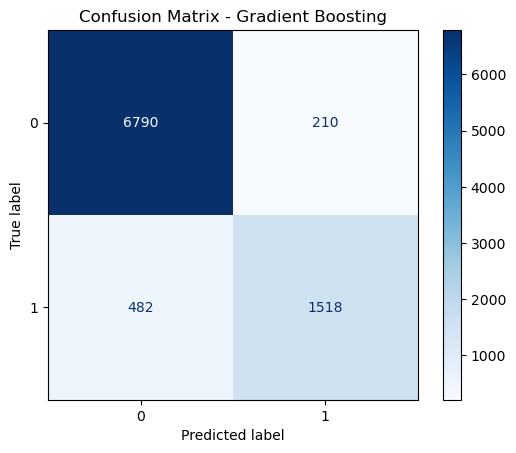

Gradient Boosting         |ROC_AUC: 0.8645 
K-Nearest Neighbors       
 [[6639  361]
 [ 593 1407]] 
               precision    recall  f1-score   support

           0       0.92      0.95      0.93      7000
           1       0.80      0.70      0.75      2000

    accuracy                           0.89      9000
   macro avg       0.86      0.83      0.84      9000
weighted avg       0.89      0.89      0.89      9000



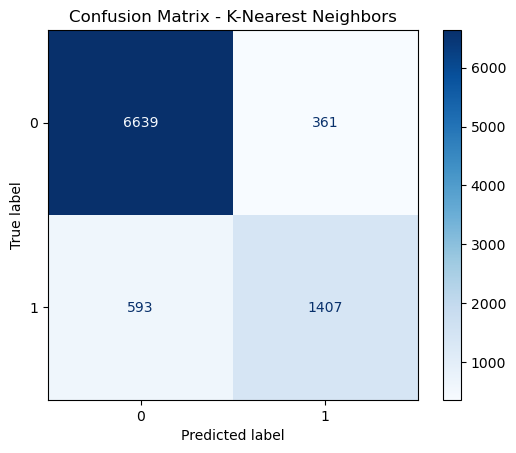

K-Nearest Neighbors       |ROC_AUC: 0.8260 
Decision Tree             
 [[6770  230]
 [ 703 1297]] 
               precision    recall  f1-score   support

           0       0.91      0.97      0.94      7000
           1       0.85      0.65      0.74      2000

    accuracy                           0.90      9000
   macro avg       0.88      0.81      0.84      9000
weighted avg       0.89      0.90      0.89      9000



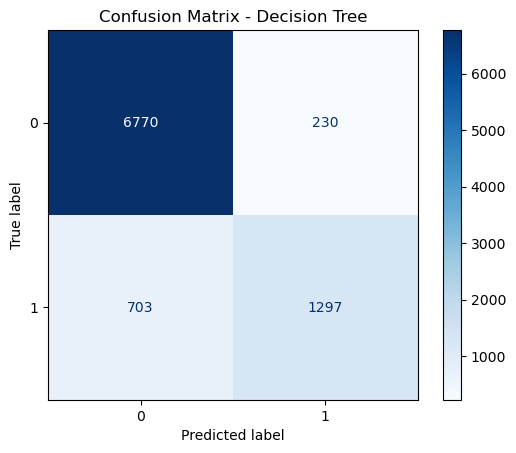

Decision Tree             |ROC_AUC: 0.8078 
Support Vector Machine    
 [[6732  268]
 [ 488 1512]] 
               precision    recall  f1-score   support

           0       0.93      0.96      0.95      7000
           1       0.85      0.76      0.80      2000

    accuracy                           0.92      9000
   macro avg       0.89      0.86      0.87      9000
weighted avg       0.91      0.92      0.91      9000



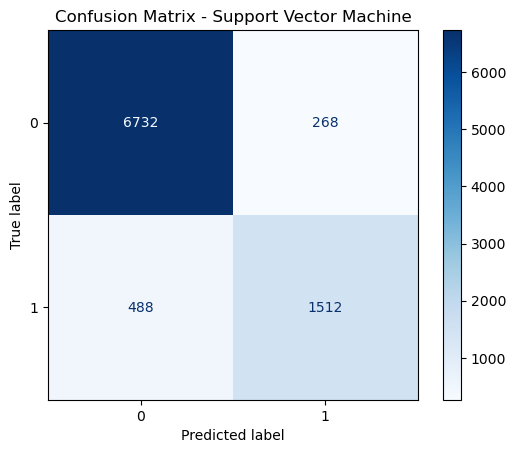

Support Vector Machine    |ROC_AUC: 0.8589 


In [67]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42)
}

results_no_pca = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train);
    y_pred = model.predict(X_test_scaled)

    roc = roc_auc_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    results_no_pca[name] = {'Accuracy': accuracy, 'ROC_AUC': roc}

    confusion = confusion_matrix(y_test, y_pred)
    classification_rep = classification_report(y_test, y_pred)
    print(f"{name:25s}","\n",confusion_matrix(y_test, y_pred),"\n",classification_rep)
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=model.classes_)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    print(f"{name:25s} |ROC_AUC: {roc:.4f} ")

Logistic Regression       
 [[6603  397]
 [ 500 1500]] 
               precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.79      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000



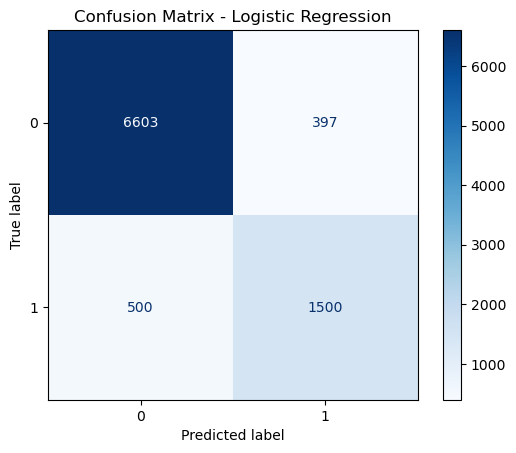

Logistic Regression       |ROC_AUC: 0.8466 
Random Forest             
 [[6730  270]
 [ 523 1477]] 
               precision    recall  f1-score   support

           0       0.93      0.96      0.94      7000
           1       0.85      0.74      0.79      2000

    accuracy                           0.91      9000
   macro avg       0.89      0.85      0.87      9000
weighted avg       0.91      0.91      0.91      9000



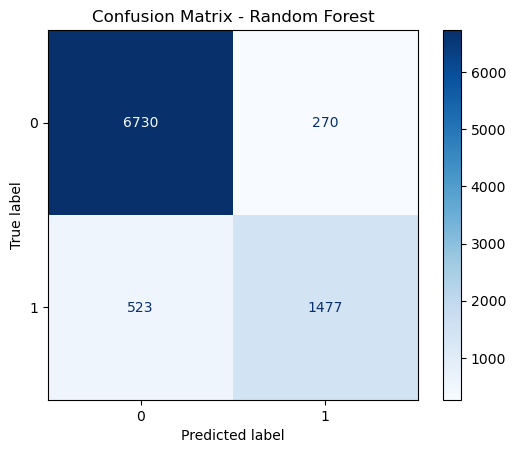

Random Forest             |ROC_AUC: 0.8500 
XGBoost                   
 [[6655  345]
 [ 475 1525]] 
               precision    recall  f1-score   support

           0       0.93      0.95      0.94      7000
           1       0.82      0.76      0.79      2000

    accuracy                           0.91      9000
   macro avg       0.87      0.86      0.87      9000
weighted avg       0.91      0.91      0.91      9000



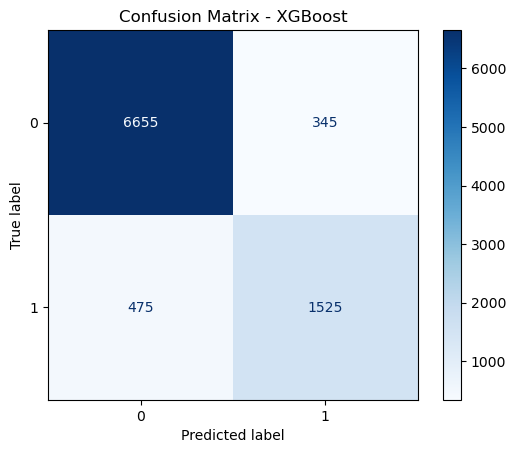

XGBoost                   |ROC_AUC: 0.8566 
Gradient Boosting         
 [[6721  279]
 [ 574 1426]] 
               precision    recall  f1-score   support

           0       0.92      0.96      0.94      7000
           1       0.84      0.71      0.77      2000

    accuracy                           0.91      9000
   macro avg       0.88      0.84      0.86      9000
weighted avg       0.90      0.91      0.90      9000



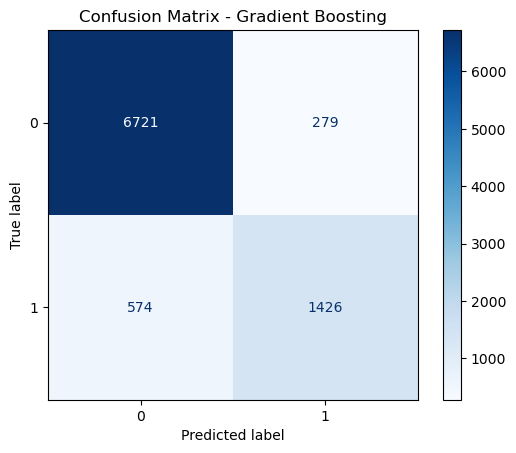

Gradient Boosting         |ROC_AUC: 0.8366 
K-Nearest Neighbors       
 [[6629  371]
 [ 595 1405]] 
               precision    recall  f1-score   support

           0       0.92      0.95      0.93      7000
           1       0.79      0.70      0.74      2000

    accuracy                           0.89      9000
   macro avg       0.85      0.82      0.84      9000
weighted avg       0.89      0.89      0.89      9000



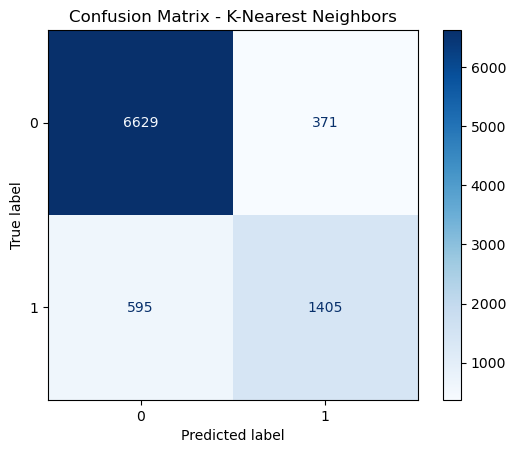

K-Nearest Neighbors       |ROC_AUC: 0.8247 
Decision Tree             
 [[6677  323]
 [1049  951]] 
               precision    recall  f1-score   support

           0       0.86      0.95      0.91      7000
           1       0.75      0.48      0.58      2000

    accuracy                           0.85      9000
   macro avg       0.81      0.71      0.74      9000
weighted avg       0.84      0.85      0.83      9000



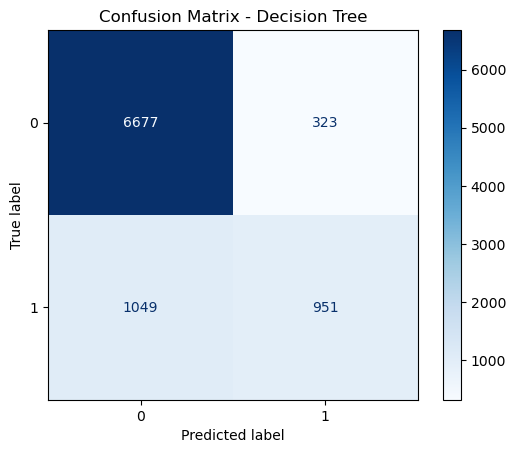

Decision Tree             |ROC_AUC: 0.7147 
Support Vector Machine    
 [[6730  270]
 [ 488 1512]] 
               precision    recall  f1-score   support

           0       0.93      0.96      0.95      7000
           1       0.85      0.76      0.80      2000

    accuracy                           0.92      9000
   macro avg       0.89      0.86      0.87      9000
weighted avg       0.91      0.92      0.91      9000



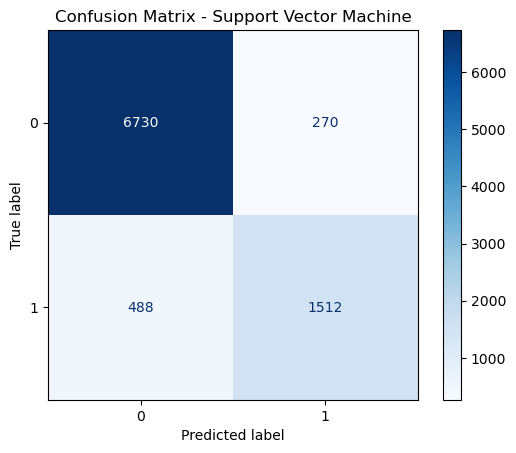

Support Vector Machine    |ROC_AUC: 0.8587 


In [68]:


results_pca = {}
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    roc = roc_auc_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    results_pca[name] = {'Accuracy': accuracy, 'ROC_AUC': roc}

    confusion = confusion_matrix(y_test, y_pred)
    classification_rep = classification_report(y_test, y_pred)
    print(f"{name:25s}","\n",confusion_matrix(y_test, y_pred),"\n",classification_rep)
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=model.classes_)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    print(f"{name:25s} |ROC_AUC: {roc:.4f} ")

In [69]:
# RESULTS COMPARISON
model_names = list(models.keys())
acc_no_pca = [results_no_pca[m]['Accuracy'] for m in model_names]
acc_pca = [results_pca[m]['Accuracy'] for m in model_names]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=model_names, y=acc_no_pca,
    name='Without PCA (Original Scaled)',
    marker_color='#2c3e50',
    text=[f"{val:.3f}" for val in acc_no_pca],
    textposition='auto'
))

fig.add_trace(go.Bar(
    x=model_names, y=acc_pca,
    name='With PCA (Reduced Dimensions)',
    marker_color='#e74c3c',
    text=[f"{val:.3f}" for val in acc_pca],
    textposition='auto'
))

fig.update_layout(
    title='Model Accuracy Comparison: Without PCA vs With PCA',
    xaxis_tickfont_size=14,
    yaxis=dict(title='Accuracy Score', titlefont_size=16, tickfont_size=14, range=[0, 1.1]),
    legend=dict(x=0.01, y=1.05, orientation="h"),
    barmode='group',
    bargap=0.15,
    bargroupgap=0.1,
    height=600
)

fig.show()


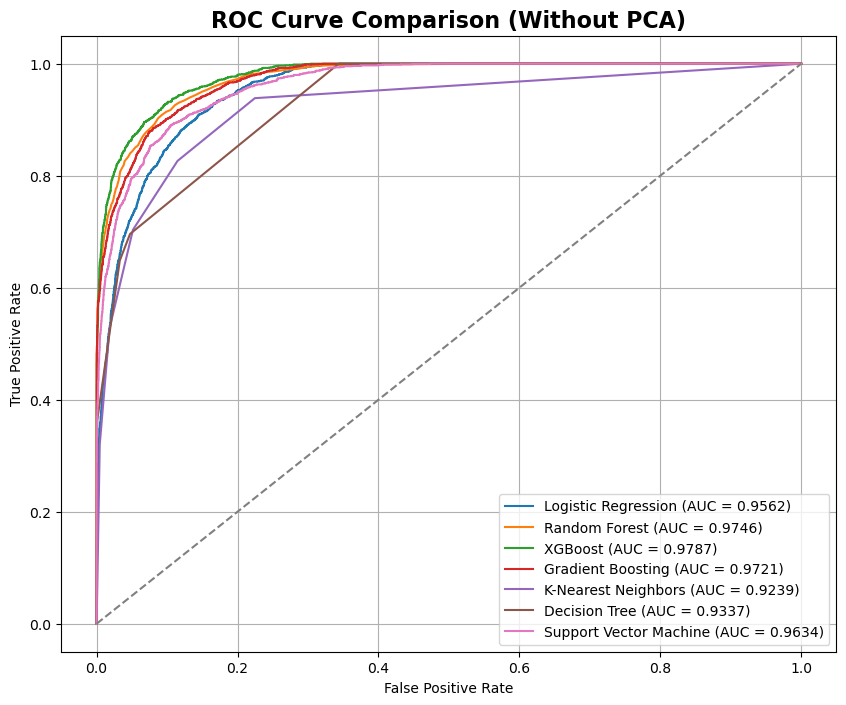

In [70]:
plt.figure(figsize=(10, 8))
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_probs = model.decision_function(X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Without PCA)', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()

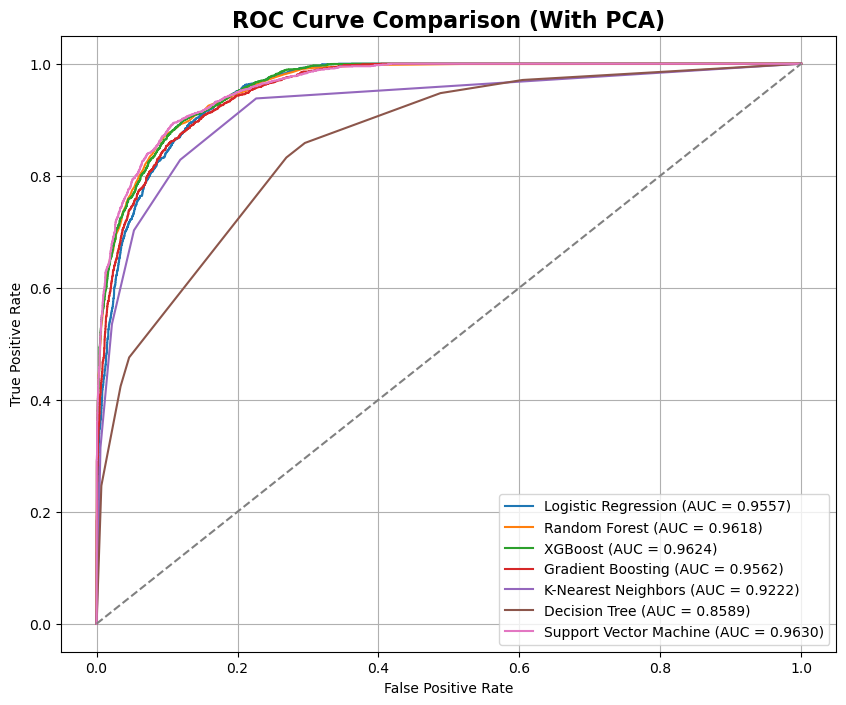

In [71]:
plt.figure(figsize=(10, 8))
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test_pca)[:, 1]
    else:
        y_probs = model.decision_function(X_test_pca)
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (With PCA)', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()